# Acrobot DQN

## 实验目标

本实验使用 `DQN` 训练 Acrobot 的离散动作策略。目标是让智能体学会通过离散力矩在双连杆系统中逐步积累动能，把末端摆到目标高度以上。这里的重点不仅是把训练跑起来，还要把 `DQN` 在连续状态、离散动作控制任务中的价值学习逻辑讲清楚。


## 为什么这里选择 DQN

Acrobot 是经典的离散动作深度强化学习环境之一，原因很直接：

- 动作空间离散，适合 Q 值方法
- 状态空间连续，不能再用表格直接枚举
- 任务回报稠密但控制链条较长，能体现经验回放与目标网络的作用
- 相比 CartPole，它更能体现 `DQN` 在复杂摆动控制里的训练难点

因此，这里优先使用 `DQN`，是为了把经典深度价值学习在更难离散控制任务中的收敛过程讲清楚。


## 收敛判断方式

这个 notebook 不会笼统地说“已经学会”，而是通过几组具体信号判断训练是否进入稳定阶段：

- episode return 是否持续改善
- 最近回合平均回报是否逐步接近或优于 `-100`
- 最近成功率是否明显高于随机基线
- 固定评估阶段的平均回报和成功率是否达到稳定水平
- 策略切片图上是否出现连贯的力矩选择边界

只有这些信号同时成立，才说明 `DQN` 不是偶然摆上去几次，而是真的学到了有效的能量积累模式。


## 设备与并行说明

- 本实验固定使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不引入并行环境

原因是这类经典 `DQN` 实验的关键不在多进程采样，而在经验回放、目标网络和训练预算是否足够稳定。


In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from tqdm.auto import tqdm


In [2]:
ENV_ID = "Acrobot-v1"
TOTAL_TIMESTEPS = 250000
LEARNING_RATE = 6.3e-4
BUFFER_SIZE = 100000
LEARNING_STARTS = 1000
BATCH_SIZE = 128
GAMMA = 0.99
TRAIN_FREQ = 16
GRADIENT_STEPS = 8
TARGET_UPDATE_INTERVAL = 250
EXPLORATION_FRACTION = 0.4
EXPLORATION_INITIAL_EPS = 1.0
EXPLORATION_FINAL_EPS = 0.05
EVAL_EPISODES = 100
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
MAX_STEPS = 500
SUCCESS_THRESHOLD_RETURN = -100
SEED = 42
DEVICE = "cpu"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


## 参数选择说明

这里的参数选择明显向“更容易收敛”倾斜，而不是追求与前面实验完全对称：

- `TOTAL_TIMESTEPS = 250000`：给 Acrobot 明显更充分的训练预算
- `LEARNING_RATE = 6.3e-4`：采用偏积极但仍常见的 DQN 学习率
- `BUFFER_SIZE = 100000`：扩大经验回放容量，减少状态相关性
- `TRAIN_FREQ = 16` 与 `GRADIENT_STEPS = 8`：降低每步更新频率，但每次做更成块的优化，提升训练稳定性
- `TARGET_UPDATE_INTERVAL = 250`：更频繁地同步目标网络，减小目标漂移
- `EXPLORATION_FRACTION = 0.4`：保留更长探索阶段，给上摆任务更多状态覆盖
- `SUCCESS_THRESHOLD_RETURN = -100`：采用经典求解标准附近的判断线

如果训练后评估回报仍明显差于 `-100`，优先调整的方向通常是：

- 继续提高 `TOTAL_TIMESTEPS`
- 放慢探索收缩
- 增大网络宽度
- 微调 `TRAIN_FREQ` 与 `GRADIENT_STEPS`


In [3]:
class EpisodeStatsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.episode_successes = []
        self.exploration_rates = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                episode_return = float(info["episode"]["r"])
                episode_length = int(info["episode"]["l"])
                self.episode_returns.append(episode_return)
                self.episode_lengths.append(episode_length)
                self.episode_successes.append(int(episode_return >= SUCCESS_THRESHOLD_RETURN))
                self.exploration_rates.append(float(self.model.exploration_rate))
        return True


In [4]:
train_env = Monitor(gym.make(ENV_ID))
callback = EpisodeStatsCallback()

model = DQN(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    gamma=GAMMA,
    train_freq=TRAIN_FREQ,
    gradient_steps=GRADIENT_STEPS,
    target_update_interval=TARGET_UPDATE_INTERVAL,
    exploration_fraction=EXPLORATION_FRACTION,
    exploration_initial_eps=EXPLORATION_INITIAL_EPS,
    exploration_final_eps=EXPLORATION_FINAL_EPS,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=0,
    device=DEVICE,
    seed=SEED,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=True)
train_env.close()


Output()

In [5]:
episode_return_series = pd.Series(callback.episode_returns, dtype=float)
episode_length_series = pd.Series(callback.episode_lengths, dtype=float)
episode_success_series = pd.Series(callback.episode_successes, dtype=float)
exploration_series = pd.Series(callback.exploration_rates, dtype=float)

rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_length = episode_length_series.rolling(50).mean() if len(episode_length_series) >= 50 else episode_length_series
rolling_success = episode_success_series.rolling(50).mean() if len(episode_success_series) >= 50 else episode_success_series
rolling_exploration = exploration_series.rolling(50).mean() if len(exploration_series) >= 50 else exploration_series


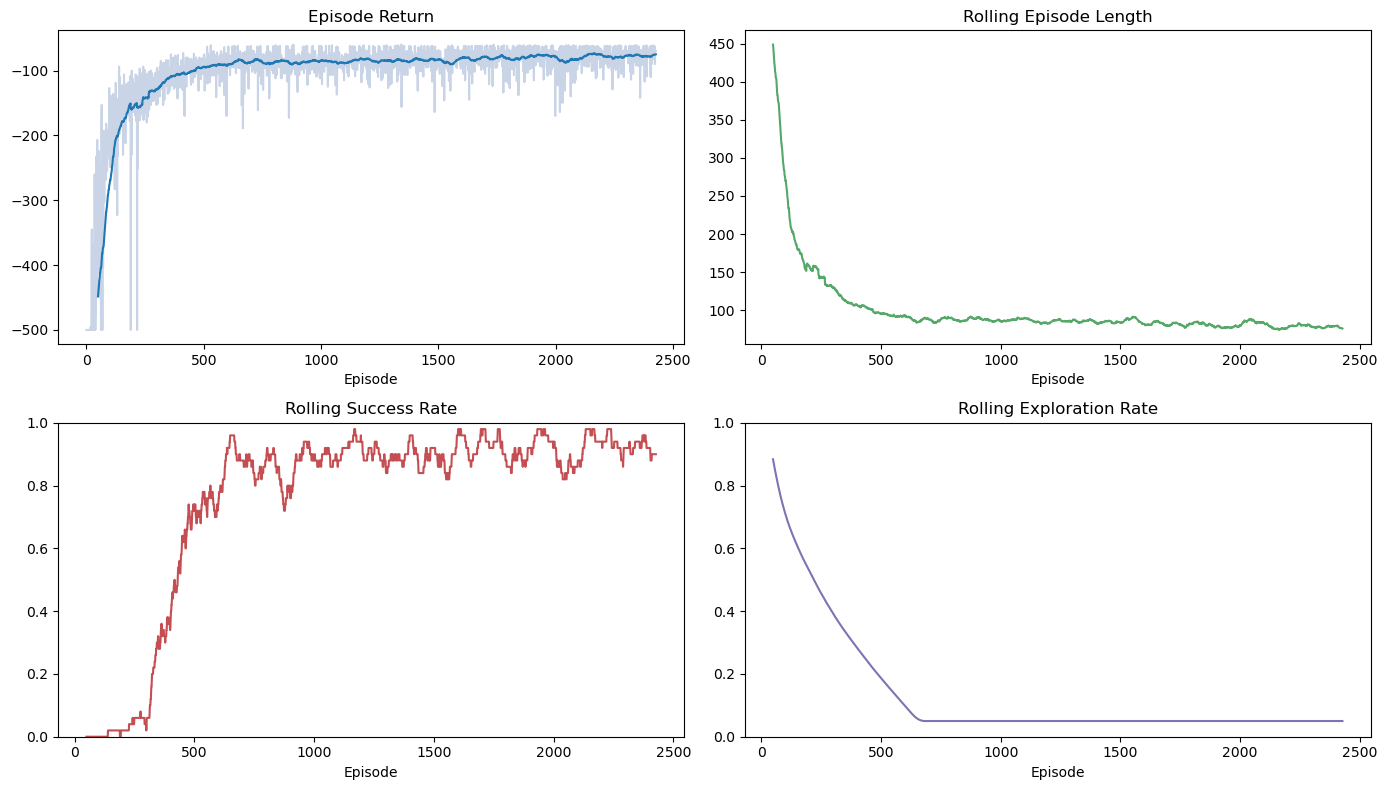

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(callback.episode_returns, alpha=0.30, color="#4c72b0")
axes[0, 0].plot(rolling_return, color="#1f77b4")
axes[0, 0].set_title("Episode Return")
axes[0, 0].set_xlabel("Episode")

axes[0, 1].plot(rolling_length, color="#55a868")
axes[0, 1].set_title("Rolling Episode Length")
axes[0, 1].set_xlabel("Episode")

axes[1, 0].plot(rolling_success, color="#c44e52")
axes[1, 0].set_title("Rolling Success Rate")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylim(0, 1)

axes[1, 1].plot(rolling_exploration, color="#8172b3")
axes[1, 1].set_title("Rolling Exploration Rate")
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dqn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
def q_values_for_state(state):
    state_tensor = torch.tensor(state, dtype=torch.float32, device=model.device).unsqueeze(0)
    with torch.no_grad():
        q_values = model.q_net(state_tensor).cpu().numpy().squeeze(0)
    return q_values


def build_policy_slice():
    vel1 = np.linspace(-6.0, 6.0, 41)
    vel2 = np.linspace(-12.0, 12.0, 41)
    policy_map = np.zeros((len(vel1), len(vel2)), dtype=int)
    value_map = np.zeros((len(vel1), len(vel2)), dtype=float)

    for i, theta_dot_1 in enumerate(vel1):
        for j, theta_dot_2 in enumerate(vel2):
            state = np.array([1.0, 0.0, 1.0, 0.0, theta_dot_1, theta_dot_2], dtype=np.float32)
            q_vals = q_values_for_state(state)
            policy_map[i, j] = int(np.argmax(q_vals))
            value_map[i, j] = float(np.max(q_vals))

    return vel1, vel2, policy_map, value_map


vel1, vel2, policy_map, value_map = build_policy_slice()


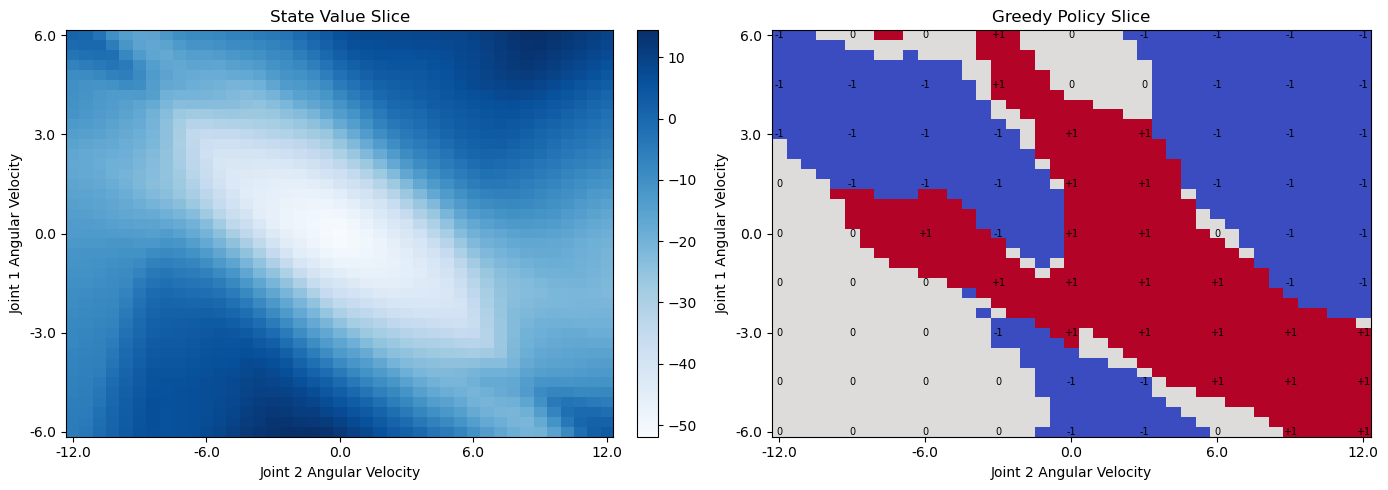

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(value_map, origin="lower", aspect="auto", cmap="Blues")
axes[0].set_title("State Value Slice")
axes[0].set_xlabel("Joint 2 Angular Velocity")
axes[0].set_ylabel("Joint 1 Angular Velocity")
axes[0].set_xticks(np.linspace(0, len(vel2) - 1, 5, dtype=int))
axes[0].set_xticklabels([f"{vel2[idx]:.1f}" for idx in np.linspace(0, len(vel2) - 1, 5, dtype=int)])
axes[0].set_yticks(np.linspace(0, len(vel1) - 1, 5, dtype=int))
axes[0].set_yticklabels([f"{vel1[idx]:.1f}" for idx in np.linspace(0, len(vel1) - 1, 5, dtype=int)])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(policy_map, origin="lower", aspect="auto", cmap="coolwarm", vmin=0, vmax=2)
axes[1].set_title("Greedy Policy Slice")
axes[1].set_xlabel("Joint 2 Angular Velocity")
axes[1].set_ylabel("Joint 1 Angular Velocity")
axes[1].set_xticks(np.linspace(0, len(vel2) - 1, 5, dtype=int))
axes[1].set_xticklabels([f"{vel2[idx]:.1f}" for idx in np.linspace(0, len(vel2) - 1, 5, dtype=int)])
axes[1].set_yticks(np.linspace(0, len(vel1) - 1, 5, dtype=int))
axes[1].set_yticklabels([f"{vel1[idx]:.1f}" for idx in np.linspace(0, len(vel1) - 1, 5, dtype=int)])

label_map = {0: "-1", 1: "0", 2: "+1"}
for i in range(0, len(vel1), 5):
    for j in range(0, len(vel2), 5):
        axes[1].text(j, i, label_map[int(policy_map[i, j])], ha="center", va="center", color="black", fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "dqn_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
eval_env = gym.make(ENV_ID)
eval_returns = []
eval_lengths = []
eval_successes = []

for episode in tqdm(range(EVAL_EPISODES), desc="Policy evaluation"):
    obs, info = eval_env.reset(seed=SEED + 20000 + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(int(action))
        total_reward += reward
        if terminated or truncated:
            episode_length = step + 1
            break
    else:
        episode_length = MAX_STEPS

    eval_returns.append(total_reward)
    eval_lengths.append(episode_length)
    eval_successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))

eval_env.close()


Policy evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

In [10]:
eval_avg_return = float(np.mean(eval_returns))
eval_return_std = float(np.std(eval_returns))
eval_avg_length = float(np.mean(eval_lengths))
eval_success_rate = float(np.mean(eval_successes))

metrics = pd.DataFrame(
    {
        "metric": [
            "device",
            "total_timesteps",
            "recent_episode_return_last_50",
            "recent_episode_length_last_50",
            "recent_success_rate_last_50",
            "evaluation_average_return",
            "evaluation_return_std",
            "evaluation_average_length",
            "evaluation_success_rate",
        ],
        "value": [
            DEVICE,
            TOTAL_TIMESTEPS,
            float(episode_return_series.tail(50).mean()) if len(episode_return_series) > 0 else 0.0,
            float(episode_length_series.tail(50).mean()) if len(episode_length_series) > 0 else 0.0,
            float(episode_success_series.tail(50).mean()) if len(episode_success_series) > 0 else 0.0,
            eval_avg_return,
            eval_return_std,
            eval_avg_length,
            eval_success_rate,
        ],
    }
)
metrics


,metric,value
0,device,cpu
1,total_timesteps,250000
2,recent_episode_return_last_50,-75.04
3,recent_episode_length_last_50,76.04
4,recent_success_rate_last_50,0.9
5,evaluation_average_return,-70.74
6,evaluation_return_std,10.122865
7,evaluation_average_length,71.74
8,evaluation_success_rate,0.97


In [11]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 30000 + rollout_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = rollout_env.step(int(action))
        total_reward += reward

        if terminated or truncated:
            final_frame = rollout_env.render()
            if final_frame is not None:
                frames.append(final_frame)
            rollout_summaries.append(
                {
                    "rollout_index": rollout_idx + 1,
                    "seed": SEED + 30000 + rollout_idx,
                    "total_reward": total_reward,
                    "steps": step + 1,
                }
            )
            break

    rollout_env.close()
    if frames:
        imageio.mimsave(RESULTS_DIR / f"dqn_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)


In [12]:
metrics.to_csv(RESULTS_DIR / "dqn_metrics.csv", index=False)
pd.DataFrame({"episode_return": callback.episode_returns}).to_csv(RESULTS_DIR / "dqn_episode_returns.csv", index=False)
pd.DataFrame({"episode_length": callback.episode_lengths}).to_csv(RESULTS_DIR / "dqn_episode_lengths.csv", index=False)
pd.DataFrame({"episode_success": callback.episode_successes}).to_csv(RESULTS_DIR / "dqn_episode_successes.csv", index=False)
pd.DataFrame({"evaluation_return": eval_returns, "evaluation_length": eval_lengths, "evaluation_success": eval_successes}).to_csv(RESULTS_DIR / "dqn_eval_results.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "dqn_rollout_summary.csv", index=False)

print(f"Recent average return (last 50): {episode_return_series.tail(50).mean():.2f}")
print(f"Recent average length (last 50): {episode_length_series.tail(50).mean():.2f}")
print(f"Recent success rate (last 50): {episode_success_series.tail(50).mean():.4f}")
print(f"Evaluation average return: {eval_avg_return:.2f}")
print(f"Evaluation average length: {eval_avg_length:.2f}")
print(f"Evaluation success rate: {eval_success_rate:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Recent average return (last 50): -75.04
Recent average length (last 50): 76.04
Recent success rate (last 50): 0.9000
Evaluation average return: -70.74
Evaluation average length: 71.74
Evaluation success rate: 0.9700
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/09-acrobot-dqn/results


## 结果解读

训练完成后，重点观察以下内容：

- episode return 是否持续改善
- 最近平均回报是否逐步接近或优于 `-100`
- 成功率是否从接近随机水平明显提升
- 策略切片图上是否出现连贯的力矩选择边界
- 固定评估阶段是否达到较稳定的平均回报水平

如果这些现象都成立，就说明 `DQN` 已经在 Acrobot 里学到了有效的能量积累策略。这个实验最重要的意义在于，它展示了经典深度价值学习在更难摆动控制任务上的收敛过程。
